In [1]:
from google.colab import files
uploaded = files.upload()

Saving student-lifestyle-and-stress-dataset.csv to student-lifestyle-and-stress-dataset.csv


In [2]:
import pandas as pd
df = pd.read_csv("student-lifestyle-and-stress-dataset.csv")
df

,Student_Type,Sleep_Hours,Study_Hours,Social_Media_Hours,Attendance,Exam_Pressure,Family_Support,Month,Stress_Level
0,school,6.868702,1.711722,3.176942,NaN,8.0,7.0,2.0,1
1,school,8.519088,3.251084,3.880787,93.978465,6.0,4.0,3.0,1
2,college,4.498770,6.306885,2.936172,64.421253,7.0,1.0,12.0,1
3,school,8.591223,2.384922,5.222832,81.868960,2.0,7.0,7.0,0
4,college,5.329293,9.345179,7.815869,85.847982,5.0,6.0,10.0,1
...,...,...,...,...,...,...,...,...,...
25495,college,7.803069,7.328193,2.018277,75.435607,5.0,1.0,12.0,0
25496,school,6.734607,2.680109,3.355559,63.387386,8.0,9.0,2.0,1
25497,college,7.701671,2.631250,2.948252,79.818930,4.0,3.0,4.0,1
25498,school,5.903426,3.450424,6.823894,96.680773,2.0,6.0,6.0,0


In [3]:
df.isnull().sum()

,0
Student_Type,1252
Sleep_Hours,1333
Study_Hours,1277
Social_Media_Hours,1312
Attendance,1305
Exam_Pressure,1270
Family_Support,1291
Month,1314
Stress_Level,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25500 entries, 0 to 25499
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Student_Type        24248 non-null  object 
 1   Sleep_Hours         24167 non-null  float64
 2   Study_Hours         24223 non-null  float64
 3   Social_Media_Hours  24188 non-null  float64
 4   Attendance          24195 non-null  float64
 5   Exam_Pressure       24230 non-null  float64
 6   Family_Support      24209 non-null  float64
 7   Month               24186 non-null  float64
 8   Stress_Level        25500 non-null  int64  
dtypes: float64(7), int64(1), object(1)
memory usage: 1.8+ MB


In [5]:
X = df.drop(columns=['Stress_Level'])
Y = df['Stress_Level']

In [6]:
from sklearn.impute import SimpleImputer
num_cols = X.select_dtypes(include=['int64','float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns
num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')
X[num_cols] = num_imputer.fit_transform(X[num_cols])
X[cat_cols] = cat_imputer.fit_transform(X[cat_cols])

In [7]:
X.isnull().sum()

,0
Student_Type,0
Sleep_Hours,0
Study_Hours,0
Social_Media_Hours,0
Attendance,0
Exam_Pressure,0
Family_Support,0
Month,0


In [8]:
cols = ['Student_Type']
X = pd.get_dummies(X,columns=cols,dtype=int)

In [9]:
X

,Sleep_Hours,Study_Hours,Social_Media_Hours,Attendance,Exam_Pressure,Family_Support,Month,Student_Type_college,Student_Type_school,Student_Type_working_student
0,6.868702,1.711722,3.176942,81.942959,8.0,7.0,2.0,0,1,0
1,8.519088,3.251084,3.880787,93.978465,6.0,4.0,3.0,0,1,0
2,4.498770,6.306885,2.936172,64.421253,7.0,1.0,12.0,1,0,0
3,8.591223,2.384922,5.222832,81.868960,2.0,7.0,7.0,0,1,0
4,5.329293,9.345179,7.815869,85.847982,5.0,6.0,10.0,1,0,0
...,...,...,...,...,...,...,...,...,...,...
25495,7.803069,7.328193,2.018277,75.435607,5.0,1.0,12.0,1,0,0
25496,6.734607,2.680109,3.355559,63.387386,8.0,9.0,2.0,0,1,0
25497,7.701671,2.631250,2.948252,79.818930,4.0,3.0,4.0,1,0,0
25498,5.903426,3.450424,6.823894,96.680773,2.0,6.0,6.0,0,1,0


In [10]:
 from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

In [11]:
df['Stress_Level'].value_counts()

,count
Stress_Level,
0,17853
1,7647


In [12]:
df['Stress_Level'].value_counts(normalize=True)*100

,proportion
Stress_Level,
0,70.011765
1,29.988235


In [13]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_resampled,Y_resampled = smote.fit_resample(X,Y)

In [14]:
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

# Using Logistic Regression

In [15]:
from sklearn.linear_model import LogisticRegression
LR = LogisticRegression(max_iter=1000)
LR.fit(X_train,Y_train)

LogisticRegression(max_iter=1000)

In [16]:
y_predict = LR.predict(X_test)
y_predict

array([0, 0, 1, ..., 0, 0, 0])

In [17]:
from sklearn.metrics import accuracy_score , precision_score , recall_score , f1_score
print("Accuracy : ",accuracy_score(Y_test,y_predict))
print("Precision : ", precision_score(Y_test,y_predict))
print("Recall : ", recall_score(Y_test,y_predict))
print("F1 Score : ",f1_score(Y_test,y_predict))

Accuracy :  0.8152941176470588
Precision :  0.7430610626486915
Recall :  0.602572347266881
F1 Score :  0.6654829545454546


In [18]:
train_score = LR.score(X_train, Y_train)
test_score  = LR.score(X_test, Y_test)
print(f"Train R²: {train_score:.4f}")
print(f"Test R² : {test_score:.4f}")

Train R²: 0.8152
Test R² : 0.8153


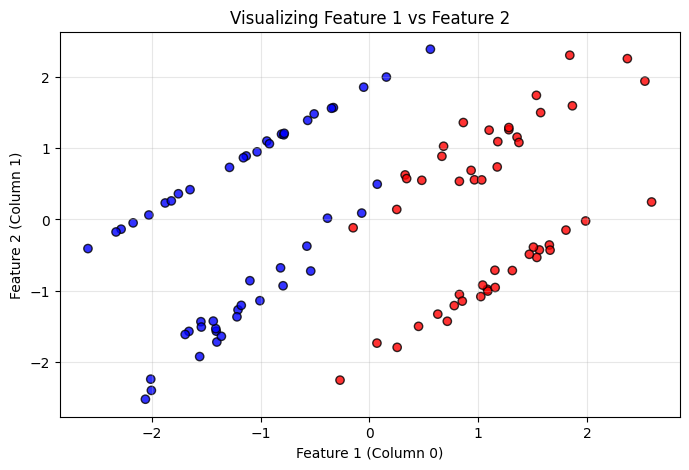

In [19]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification

# Generate a quick dummy dataset (100 samples, 2 features)
X, y = make_classification(n_samples=100, n_features=2, n_informative=2, n_redundant=0, random_state=42)

plt.figure(figsize=(8, 5))

# X[:, 0] grabs all rows for Column 0 (Feature 1) -> Passed to the X-axis
# X[:, 1] grabs all rows for Column 1 (Feature 2) -> Passed to the Y-axis
# c=y colors the points automatically based on their class (0 or 1)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolors='k', alpha=0.8)

plt.title('Visualizing Feature 1 vs Feature 2')
plt.xlabel('Feature 1 (Column 0)')
plt.ylabel('Feature 2 (Column 1)')
plt.grid(True, alpha=0.3)

plt.show()

# Using SVM

In [20]:
from sklearn.svm import SVC
model = SVC(kernel='linear')
model.fit(X_train,Y_train)

SVC(kernel='linear')

In [21]:
y_predict = model.predict(X_test)

In [23]:
from sklearn.metrics import accuracy_score , precision_score , recall_score ,f1_score
print("Accuracy :",accuracy_score(Y_test,y_predict))
print("Precision :",precision_score(Y_test,y_predict))
print("recall :",recall_score(Y_test,y_predict))
print("F1 score :",f1_score(Y_test,y_predict))

Accuracy : 0.8152941176470588
Precision : 0.7442231075697211
recall : 0.6006430868167203
F1 score : 0.6647686832740214


In [22]:
from sklearn.tree import DecisionTreeClassifier,plot_tree

In [24]:
from sklearn.model_selection import GridSearchCV
params = {
    "max_depth" : [1,2,3,4,5,6,7,8,9,10],
    "criterion" : ["gini","entropy"],
    "min_samples_split" : [1,2,3,4,5,6,7,8,9,10],
    "min_samples_leaf" : [1,2,3,4,5,6,7,8,9,10],
}
grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    params,
    cv = 5,
    scoring = "accuracy",
    verbose=1
)
grid.fit(X_train,Y_train)

Fitting 5 folds for each of 2000 candidates, totalling 10000 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
1000 fits failed out of a total of 10000.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1000 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.12/dist-packages/sklearn/

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
                         'min_samples_leaf': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
                         'min_samples_split': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]},
             scoring='accuracy', verbose=1)

In [25]:
y_predict = grid.predict(X_test)
y_predict

array([0, 0, 1, ..., 0, 0, 0])

In [26]:
from sklearn.metrics import accuracy_score
print("Accuracy :",accuracy_score(Y_test,y_predict))

Accuracy : 0.7954901960784314
